# Population raster preparation

This notebook is the reproducible source-to-analysis preparation for every available POPREG 100 m GML. It streams the nested INSPIRE `StatisticalValue` records, standardises both historical and current grid references to the same canonical `AT_CRS3035RES100m...` identifier, writes one Austria-wide GeoParquet per year, and clips one analysis-ready GeoParquet per year to the official Styria municipality boundary.

The 2019 GML was obtained from a non-official distribution channel. It is therefore treated as an unverified copy: the notebook checks its internal structure and spatial grid, compares its Styria aggregate and municipality pattern with the official annual municipality table, and compares its cell pattern with the official 2025 POPREG release. These checks can establish consistency, but cannot authenticate provenance.


## Inputs and outputs

Inputs are discovered from `OGD/Popreg_100m/GMLs/pd_popreg_100m_YYYY.gml`. The current repository contains 2019 and 2025. The official municipality boundary and annual municipality population series are read from `OGD/Gemeindegrenzen.zip` and `OGD/STMK_POP_2002_2025.csv`.

For each discovered year, the notebook writes:

- `OGD/Popreg_100m/population_100m_YYYY.geoparquet` (all Austria)
- `OGD/Popreg_100m/population_grid_styria_YYYY.geoparquet` (populated cells intersecting Styria, with outer-border geometry clipped)

Only populated source cells occur in POPREG. Empty cells are represented later by zero when these layers are joined to the complete Styria raster universe.


## 1. Imports, paths, and source discovery


In [1]:
import re
import warnings
import xml.etree.ElementTree as ET
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm, TwoSlopeNorm
from shapely.geometry import box


def discover_project_dir() -> Path:
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (candidate / "ANAL").is_dir() and (candidate / "OGD").is_dir():
            return candidate
    raise RuntimeError("Run this notebook from the project directory or one of its subdirectories.")


PROJECT_DIR = discover_project_dir()
POPREG_DIR = PROJECT_DIR / "OGD" / "Popreg_100m"
GML_DIR = POPREG_DIR / "GMLs"
BOUNDARY_PATH = PROJECT_DIR / "OGD" / "Gemeindegrenzen.zip"
MUNICIPAL_POPULATION_PATH = PROJECT_DIR / "OGD" / "STMK_POP_2002_2025.csv"
CRS = "EPSG:3035"
CELL_SIZE = 100

SOURCE_STATUS = {
    2019: "unverified copy from a non-official distribution channel",
    2025: "official Statistik Austria release",
}

source_paths = {}
for path in sorted(GML_DIR.glob("pd_popreg_100m_*.gml")):
    match = re.search(r"(19|20)\d{2}", path.stem)
    if match:
        year = int(match.group())
        if year in source_paths:
            raise ValueError(f"More than one POPREG GML found for {year}: {source_paths[year]}, {path}")
        source_paths[year] = path

if not source_paths:
    raise FileNotFoundError(f"No year-labelled POPREG GML files found in {GML_DIR}")

print("Discovered POPREG sources")
for year, path in source_paths.items():
    print(f"  {year}: {path.name} — {SOURCE_STATUS.get(year, 'source status not documented')}")


Discovered POPREG sources
  2019: pd_popreg_100m_2019.gml — unverified copy from a non-official distribution channel
  2025: pd_popreg_100m_2025.gml — official Statistik Austria release


## 2. Streaming INSPIRE GML extraction


In [2]:
NS = {
    "pd": "http://inspire.ec.europa.eu/schemas/pd/4.0",
    "xlink": "http://www.w3.org/1999/xlink",
}

# The historical file uses ...StatisticalGridCell.CRS3035RES..., whereas the
# current file uses .../AT_CRS3035RES.... Both describe the same ETRS-LAEA grid.
CELL_ID_RE = re.compile(r"(?:AT_)?CRS3035RES(?P<size>\d+)mN(?P<northing>\d+)E(?P<easting>\d+)$")


def parse_grid_cell_href(href: str) -> tuple[str, int, int, int]:
    match = CELL_ID_RE.search(href)
    if match is None:
        raise ValueError(f"Unsupported grid cell reference: {href}")
    cell_size = int(match.group("size"))
    northing = int(match.group("northing"))
    easting = int(match.group("easting"))
    cell_id = f"AT_CRS3035RES{cell_size}mN{northing}E{easting}"
    return cell_id, easting, northing, cell_size


def iter_population_cells(gml_path: Path):
    """Stream nested StatisticalValue records without loading the 300+ MB XML tree."""
    statistical_value_tag = f"{{{NS['pd']}}}StatisticalValue"
    href_key = f"{{{NS['xlink']}}}href"
    for _, element in ET.iterparse(gml_path, events=("end",)):
        if element.tag != statistical_value_tag:
            continue
        value_element = element.find("pd:value", NS)
        spatial_element = element.find(".//pd:spatial", NS)
        if value_element is None or spatial_element is None or value_element.text is None:
            element.clear()
            continue
        href = spatial_element.attrib.get(href_key)
        if not href:
            element.clear()
            continue
        cell_id, easting, northing, cell_size = parse_grid_cell_href(href)
        value = float(value_element.text)
        if not value.is_integer():
            raise ValueError(f"Non-integer population {value} in {cell_id}")
        yield {
            "population": int(value),
            "cell_id": cell_id,
            "easting": easting,
            "northing": northing,
            "cell_size_m": cell_size,
            "geometry": box(easting, northing, easting + cell_size, northing + cell_size),
        }
        element.clear()


def extract_population_gml(gml_path: Path) -> gpd.GeoDataFrame:
    records = list(iter_population_cells(gml_path))
    if not records:
        raise ValueError(f"No population grid cells found in {gml_path}")
    return gpd.GeoDataFrame(records, geometry="geometry", crs=CRS)


def validate_extracted_grid(grid: gpd.GeoDataFrame, year: int) -> dict:
    checks = {
        "rows_positive": len(grid) > 0,
        "canonical_cell_ids": grid["cell_id"].str.match(r"^AT_CRS3035RES100mN\d+E\d+$").all(),
        "unique_cell_ids": grid["cell_id"].is_unique,
        "nonnegative_integer_population": (grid["population"] >= 0).all() and np.allclose(grid["population"], np.round(grid["population"])),
        "100m_resolution": grid["cell_size_m"].eq(CELL_SIZE).all(),
        "100m_alignment": grid["easting"].mod(CELL_SIZE).eq(0).all() and grid["northing"].mod(CELL_SIZE).eq(0).all(),
        "valid_geometry": grid.geometry.is_valid.all(),
        "epsg_3035": grid.crs is not None and grid.crs.to_epsg() == 3035,
    }
    failed = [name for name, passed in checks.items() if not passed]
    if failed:
        raise ValueError(f"{year} extraction failed checks: {failed}")
    return checks


## 3. Official Styria boundary


In [3]:
def read_zipped_shapefile(zip_path: Path) -> gpd.GeoDataFrame:
    zip_uri = f"zip://{zip_path.resolve().as_posix()}"
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message=".*FLAECHE_HA parsed incompletely.*")
        return gpd.read_file(zip_uri)


municipalities = read_zipped_shapefile(BOUNDARY_PATH).to_crs(CRS)
municipalities = municipalities[["GEMNR6", "GEMNAM", "geometry"]].rename(
    columns={"GEMNR6": "municipality_id", "GEMNAM": "municipality_name"}
)
municipalities["municipality_id"] = (
    municipalities["municipality_id"].astype("string").str.strip().str.replace(r"\.0$", "", regex=True).str.zfill(5)
)
styria_boundary = (
    municipalities.geometry.union_all()
    if hasattr(municipalities.geometry, "union_all")
    else municipalities.geometry.unary_union
)
print(f"Municipalities: {len(municipalities):,}; boundary CRS: {municipalities.crs}")


Municipalities: 285; boundary CRS: EPSG:3035


## 4. Extract all available years and write Austria/Styria GeoParquets


In [4]:
population_grids = {}
styria_grids = {}
extraction_rows = []

for year, source_path in source_paths.items():
    print(f"\nExtracting {year} from {source_path.name} ...")
    grid = extract_population_gml(source_path)
    checks = validate_extracted_grid(grid, year)

    national_output = POPREG_DIR / f"population_100m_{year}.geoparquet"
    styria_output = POPREG_DIR / f"population_grid_styria_{year}.geoparquet"
    grid.to_parquet(national_output, index=False)

    # Reproduce the established downstream clip exactly, while avoiding a
    # costly intersection call for the many cells wholly inside Styria.
    styria_positions = grid.sindex.query(styria_boundary, predicate="intersects")
    styria = grid.iloc[np.unique(styria_positions)].copy().reset_index(drop=True)
    boundary_positions = styria.sindex.query(styria_boundary.boundary, predicate="intersects")
    styria.loc[boundary_positions, "geometry"] = (
        styria.iloc[boundary_positions].geometry.intersection(styria_boundary).array
    )
    styria.to_parquet(styria_output, index=False)

    population_grids[year] = grid
    styria_grids[year] = styria
    extraction_rows.append({
        "year": year,
        "source_status": SOURCE_STATUS.get(year, "not documented"),
        "austria_cells": len(grid),
        "austria_population": int(grid["population"].sum()),
        "styria_cells": len(styria),
        "styria_grid_population": int(styria["population"].sum()),
        "minimum_cell_population": int(grid["population"].min()),
        "maximum_cell_population": int(grid["population"].max()),
        "all_extraction_checks_pass": all(checks.values()),
        "national_output": national_output.name,
        "styria_output": styria_output.name,
    })
    print(f"Wrote {len(grid):,} Austria cells to {national_output.name}")
    print(f"Wrote {len(styria):,} intersecting Styria cells to {styria_output.name}")

extraction_summary = pd.DataFrame(extraction_rows).sort_values("year").reset_index(drop=True)
display(extraction_summary)



Extracting 2019 from pd_popreg_100m_2019.gml ...


Wrote 580,955 Austria cells to population_100m_2019.geoparquet
Wrote 121,992 intersecting Styria cells to population_grid_styria_2019.geoparquet

Extracting 2025 from pd_popreg_100m_2025.gml ...


Wrote 588,603 Austria cells to population_100m_2025.geoparquet
Wrote 123,403 intersecting Styria cells to population_grid_styria_2025.geoparquet


,year,source_status,austria_cells,austria_population,styria_cells,styria_grid_population,minimum_cell_population,maximum_cell_population,all_extraction_checks_pass,national_output,styria_output
0,2019,unverified copy from a non-official distributi...,580955,8858775,121992,1243846,1,1071,True,population_100m_2019.geoparquet,population_grid_styria_2019.geoparquet
1,2025,official Statistik Austria release,588603,9197213,123403,1272478,1,1295,True,population_100m_2025.geoparquet,population_grid_styria_2025.geoparquet


## 5. Descriptive comparison of available years


In [5]:
descriptive_parts = []
for year, grid in styria_grids.items():
    description = grid["population"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
    descriptive_parts.append(pd.DataFrame({year: description}))

descriptive = pd.concat(descriptive_parts, axis=1)
descriptive.columns.name = "year"
display(descriptive.round(2))

comparison = None
available_years = sorted(styria_grids)
if len(available_years) >= 2:
    first_year, last_year = available_years[0], available_years[-1]
    comparison = (
        styria_grids[first_year][["cell_id", "population", "easting", "northing"]]
        .rename(columns={"population": f"population_{first_year}"})
        .merge(
            styria_grids[last_year][["cell_id", "population"]].rename(columns={"population": f"population_{last_year}"}),
            on="cell_id",
            how="outer",
            indicator=True,
        )
    )
    for year in (first_year, last_year):
        comparison[f"population_{year}"] = comparison[f"population_{year}"].fillna(0).astype(int)
    comparison["population_change"] = comparison[f"population_{last_year}"] - comparison[f"population_{first_year}"]
    comparison["cell_status"] = comparison["_merge"].map({
        "left_only": f"only {first_year}", "right_only": f"only {last_year}", "both": "both years"
    })

    overlap_summary = pd.Series({
        "cells_in_union": len(comparison),
        f"cells_only_{first_year}": comparison["_merge"].eq("left_only").sum(),
        f"cells_only_{last_year}": comparison["_merge"].eq("right_only").sum(),
        "cells_in_both_years": comparison["_merge"].eq("both").sum(),
        "population_change_in_cell_union": comparison["population_change"].sum(),
        "pearson_correlation_in_shared_cells": comparison.loc[comparison["_merge"].eq("both"), [f"population_{first_year}", f"population_{last_year}"]].corr().iloc[0, 1],
    })
    display(overlap_summary.to_frame("value"))
    display(comparison.groupby("cell_status", observed=True).agg(cells=("cell_id", "size"), population_change=("population_change", "sum")))


year,2019,2025
count,121992.00,123403.00
mean,10.20,10.31
std,20.72,20.48
min,1.00,1.00
25%,3.00,3.00
50%,5.00,5.00
75%,10.00,10.00
90%,20.00,21.00
95%,32.00,34.00
99%,102.00,103.00


,value
cells_in_union,128057.000000
cells_only_2019,4654.000000
cells_only_2025,6065.000000
cells_in_both_years,117338.000000
population_change_in_cell_union,28632.000000
pearson_correlation_in_shared_cells,0.904267


,cells,population_change
cell_status,,
only 2019,4654,-12658
only 2025,6065,42477
both years,117338,-1187


## 6. Visual comparison


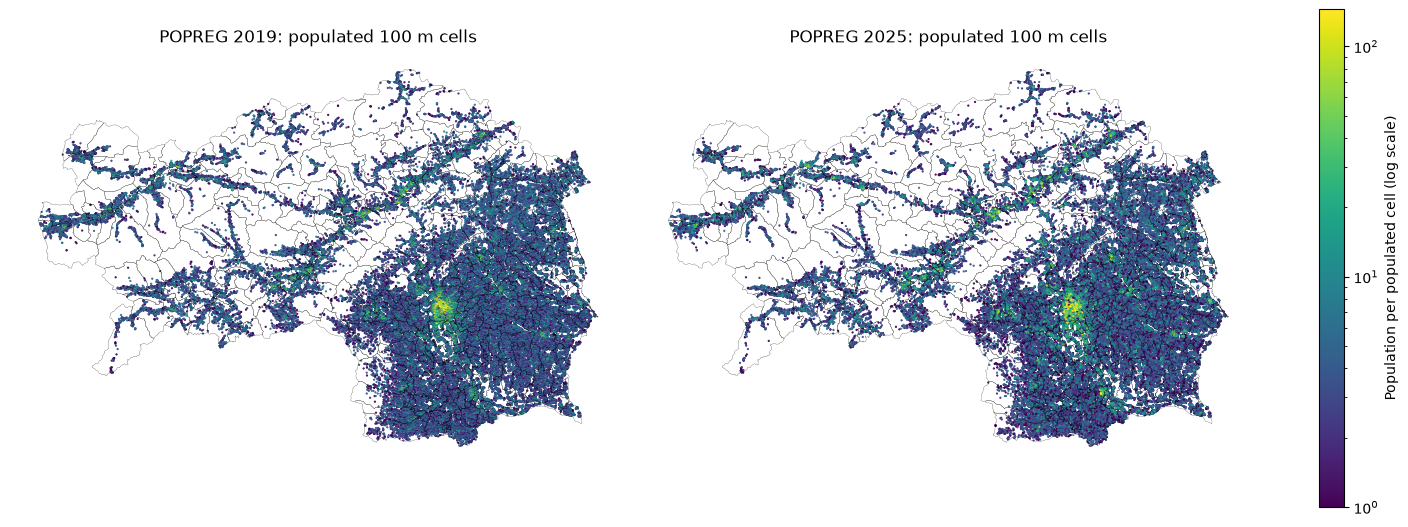

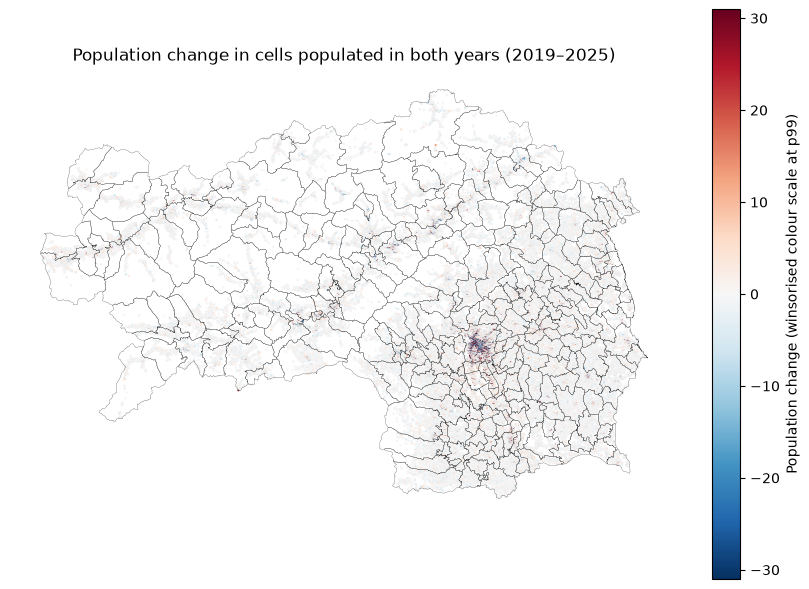

In [6]:
if len(available_years) >= 2:
    first_year, last_year = available_years[0], available_years[-1]
    positive_values = pd.concat([styria_grids[y]["population"] for y in (first_year, last_year)])
    norm = LogNorm(vmin=max(1, positive_values.min()), vmax=positive_values.quantile(0.995))

    fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)
    for axis, year in zip(axes, (first_year, last_year)):
        layer = styria_grids[year]
        points = axis.scatter(
            layer["easting"] + 50,
            layer["northing"] + 50,
            c=layer["population"],
            s=0.35,
            cmap="viridis",
            norm=norm,
            rasterized=True,
        )
        municipalities.boundary.plot(ax=axis, color="black", linewidth=0.15)
        axis.set_title(f"POPREG {year}: populated 100 m cells")
        axis.set_axis_off()
    fig.colorbar(points, ax=axes, shrink=0.72, label="Population per populated cell (log scale)")
    plt.show()

    shared = comparison.loc[comparison["_merge"].eq("both")].copy()
    change_limit = max(1, float(shared["population_change"].abs().quantile(0.99)))
    fig, axis = plt.subplots(figsize=(8, 8), constrained_layout=True)
    change_points = axis.scatter(
        shared["easting"] + 50,
        shared["northing"] + 50,
        c=shared["population_change"],
        s=0.45,
        cmap="RdBu_r",
        norm=TwoSlopeNorm(vmin=-change_limit, vcenter=0, vmax=change_limit),
        rasterized=True,
    )
    municipalities.boundary.plot(ax=axis, color="black", linewidth=0.15)
    axis.set_title(f"Population change in cells populated in both years ({first_year}–{last_year})")
    axis.set_axis_off()
    fig.colorbar(change_points, ax=axis, shrink=0.72, label="Population change (winsorised colour scale at p99)")
    plt.show()


## 7. Independent validation of the unverified 2019 copy

The official municipality population table is an independent aggregate benchmark. POPREG cells are assigned by their original 100 m cell centre. Municipality differences are expected because grid disclosure/allocation and administrative-border assignment need not reproduce published municipality totals exactly. Strong aggregate agreement and a near-perfect municipality pattern are evidence of consistency; they do not prove that the file itself came from an official server.


In [7]:
if 2019 not in styria_grids:
    print("No 2019 grid is available; source validation skipped.")
else:
    municipal_population_wide = pd.read_csv(MUNICIPAL_POPULATION_PATH, sep=";", encoding="cp1252")
    official_2019 = municipal_population_wide[["LAU_CODE", "LAU_NAME", "POP_2019"]].copy()
    official_2019["municipality_id"] = (
        official_2019["LAU_CODE"].astype("string").str.strip().str.replace(r"\.0$", "", regex=True).str.zfill(5)
    )
    official_2019["official_population_2019"] = pd.to_numeric(official_2019["POP_2019"], errors="raise")

    grid_2019 = styria_grids[2019].copy()
    grid_centres = gpd.GeoDataFrame(
        grid_2019[["cell_id", "population"]].copy(),
        geometry=gpd.points_from_xy(grid_2019["easting"] + 50, grid_2019["northing"] + 50),
        crs=CRS,
    )
    assigned = gpd.sjoin(
        grid_centres,
        municipalities[["municipality_id", "geometry"]],
        how="left",
        predicate="within",
    ).drop(columns="index_right")
    unassigned = assigned["municipality_id"].isna()
    if unassigned.any():
        nearest = gpd.sjoin_nearest(
            assigned.loc[unassigned, ["cell_id", "geometry"]],
            municipalities[["municipality_id", "geometry"]],
            how="left",
            max_distance=100,
        ).drop(columns="index_right").drop_duplicates("cell_id")
        assigned.loc[unassigned, "municipality_id"] = assigned.loc[unassigned, "cell_id"].map(
            nearest.set_index("cell_id")["municipality_id"]
        )

    grid_municipal_2019 = (
        assigned.dropna(subset=["municipality_id"])
        .groupby("municipality_id", as_index=False)["population"].sum()
        .rename(columns={"population": "grid_population_2019"})
    )
    municipality_validation = official_2019.merge(grid_municipal_2019, on="municipality_id", how="left")
    municipality_validation["grid_population_2019"] = municipality_validation["grid_population_2019"].fillna(0)
    municipality_validation["difference"] = municipality_validation["grid_population_2019"] - municipality_validation["official_population_2019"]
    municipality_validation["absolute_percentage_difference"] = (
        municipality_validation["difference"].abs() / municipality_validation["official_population_2019"] * 100
    )

    official_total = municipality_validation["official_population_2019"].sum()
    grid_total = grid_2019["population"].sum()
    validation_2019 = pd.Series({
        "source_status": SOURCE_STATUS[2019],
        "extracted_cells": len(population_grids[2019]),
        "duplicate_cell_ids": population_grids[2019]["cell_id"].duplicated().sum(),
        "invalid_geometries": (~population_grids[2019].geometry.is_valid).sum(),
        "non_100m_cells": population_grids[2019]["cell_size_m"].ne(100).sum(),
        "unassigned_styria_cell_centres": assigned["municipality_id"].isna().sum(),
        "styria_grid_population": int(grid_total),
        "official_styria_population": int(official_total),
        "styria_total_difference": int(grid_total - official_total),
        "styria_total_relative_difference_pct": (grid_total / official_total - 1) * 100,
        "municipality_population_correlation": municipality_validation[["grid_population_2019", "official_population_2019"]].corr().iloc[0, 1],
        "median_municipality_absolute_percentage_difference": municipality_validation["absolute_percentage_difference"].median(),
        "maximum_municipality_absolute_percentage_difference": municipality_validation["absolute_percentage_difference"].max(),
    })
    display(validation_2019.to_frame("value"))
    display(
        municipality_validation.sort_values("difference", key=lambda values: values.abs(), ascending=False)[
            ["municipality_id", "LAU_NAME", "grid_population_2019", "official_population_2019", "difference", "absolute_percentage_difference"]
        ].head(15)
    )

    consistency_checks = {
        "no duplicate cell IDs": validation_2019["duplicate_cell_ids"] == 0,
        "all geometries valid": validation_2019["invalid_geometries"] == 0,
        "all records are aligned 100 m cells": validation_2019["non_100m_cells"] == 0,
        "Styria total is within 5% of official municipal total": abs(validation_2019["styria_total_relative_difference_pct"]) <= 5,
        "municipality totals correlate at least 0.98 with official counts": validation_2019["municipality_population_correlation"] >= 0.98,
    }
    for label, passed in consistency_checks.items():
        print(f"{'PASS' if passed else 'REVIEW'}: {label}")
    print("\nConclusion: the 2019 copy is analytically consistent with the independent official benchmark" if all(consistency_checks.values()) else "\nConclusion: at least one 2019 consistency check requires review")
    print("Provenance remains unverified; these diagnostics do not authenticate the distribution source.")


,value
source_status,unverified copy from a non-official distributi...
extracted_cells,580955
duplicate_cell_ids,0
invalid_geometries,0
non_100m_cells,0
unassigned_styria_cell_centres,0
styria_grid_population,1243846
official_styria_population,1243052
styria_total_difference,794
styria_total_relative_difference_pct,0.063875


,municipality_id,LAU_NAME,grid_population_2019,official_population_2019,difference,absolute_percentage_difference
218,62142,Mariazell,3858,3722,136,3.653949
42,60661,Eggersdorf bei Graz,6574,6669,-95,1.424501
216,62140,Kapfenberg,22673,22753,-80,0.351602
51,60670,Premstätten,6341,6265,76,1.213089
272,62378,Fehring,7319,7246,73,1.007452
56,61012,Gralla,2439,2511,-72,2.867384
210,62128,Sankt Lorenzen im Mürztal,3680,3610,70,1.939058
19,60617,Hart bei Graz,5195,5126,69,1.346079
259,62280,Fürstenfeld,10129,10062,67,0.665872
234,62226,Lafnitz,1509,1445,64,4.429066


PASS: no duplicate cell IDs
PASS: all geometries valid
PASS: all records are aligned 100 m cells
PASS: Styria total is within 5% of official municipal total
PASS: municipality totals correlate at least 0.98 with official counts

Conclusion: the 2019 copy is analytically consistent with the independent official benchmark
Provenance remains unverified; these diagnostics do not authenticate the distribution source.


## 8. Output validation


In [8]:
for year in sorted(source_paths):
    national_path = POPREG_DIR / f"population_100m_{year}.geoparquet"
    styria_path = POPREG_DIR / f"population_grid_styria_{year}.geoparquet"
    national = gpd.read_parquet(national_path)
    styria = gpd.read_parquet(styria_path)
    assert national.crs.to_epsg() == 3035 and styria.crs.to_epsg() == 3035
    assert national["cell_id"].is_unique and styria["cell_id"].is_unique
    assert set(styria["cell_id"]).issubset(set(national["cell_id"]))
    assert national["population"].sum() == population_grids[year]["population"].sum()
    assert styria["population"].sum() == styria_grids[year]["population"].sum()
    print(f"PASS {year}: both GeoParquets reread successfully; CRS, IDs, membership, and population sums match.")


PASS 2019: both GeoParquets reread successfully; CRS, IDs, membership, and population sums match.


PASS 2025: both GeoParquets reread successfully; CRS, IDs, membership, and population sums match.
